In [10]:
library(HilbertCurve)
library(circlize)
library(GenomicRanges)
library(IRanges)
library(RColorBrewer)
library(ComplexHeatmap)
library(grid)
library(dplyr)

## Hilbert curves

In [11]:
filenames <- c("Adult->S6-KO_bins", "Adult->Old_bins", "Control->Step1_bins", "Control->Step2_bins") 

In [12]:
read.csv(paste0("~/SIRT6/HiC/!Katia_paper/Rebuttal/", filenames[1], ".csv"), header = TRUE, row.names = 1) %>% dim()

[1] 173   4

In [13]:
rcolors <- rand_color(22, transparency = 0.9, hue = "blue", luminosity = "bright")

In [14]:
blues <- brewer.pal(9, "Blues")[c(3, 5, 7)]
reds <- brewer.pal(9, "Reds")[c(3, 5, 7)]

label_colors <- c(
    "A->B"   = '#051729',
    "B->A"   = '#EF8A62',
    "wB->sB" = '#2a485a',
    "sB->wB" = '#FB6A4A',
    "sA->wA" = '#003568',
    "wA->sA" = '#CB181D'
)

  Plotted    39 bins for 'A->B'
  Plotted     1 bins for 'B->A'
  Plotted    50 bins for 'wB->sB'
  Plotted     6 bins for 'sB->wB'
  Plotted    77 bins for 'sA->wA'


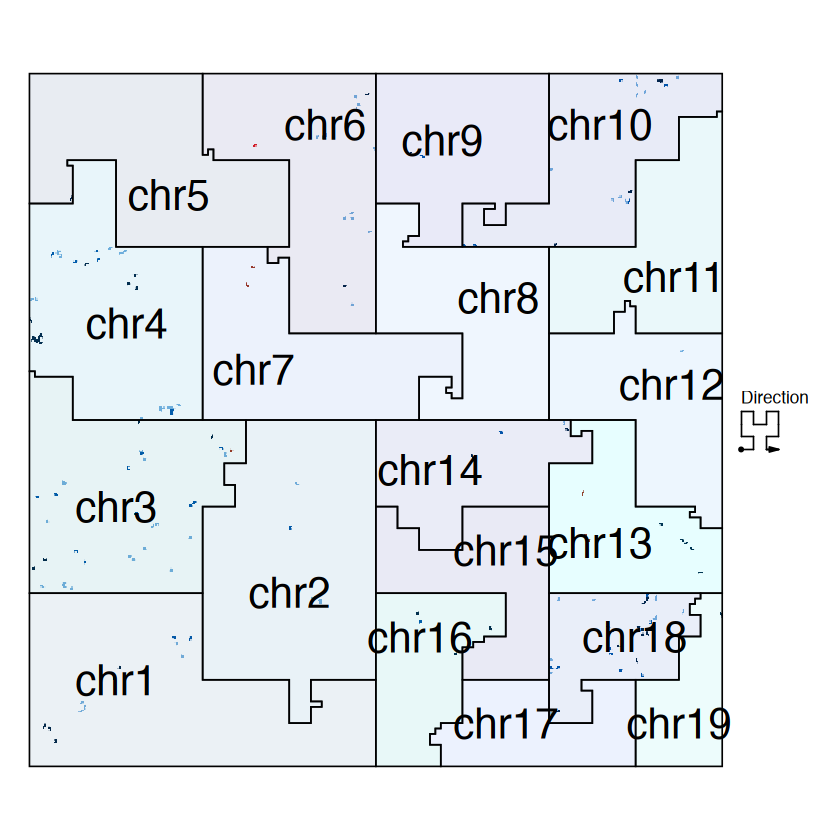

  Plotted     1 bins for 'A->B'
  Plotted     4 bins for 'wB->sB'
  Plotted    10 bins for 'sB->wB'
  Plotted     7 bins for 'sA->wA'


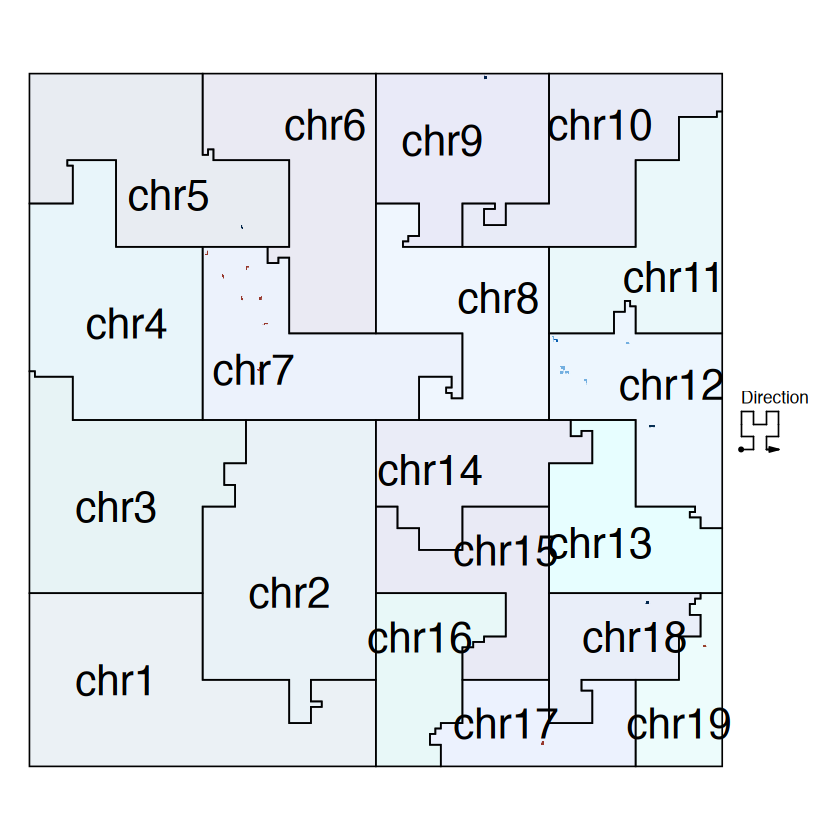

  Plotted   697 bins for 'A->B'
  Plotted    40 bins for 'B->A'
  Plotted   344 bins for 'wB->sB'
  Plotted   161 bins for 'sB->wB'
  Plotted  1299 bins for 'sA->wA'


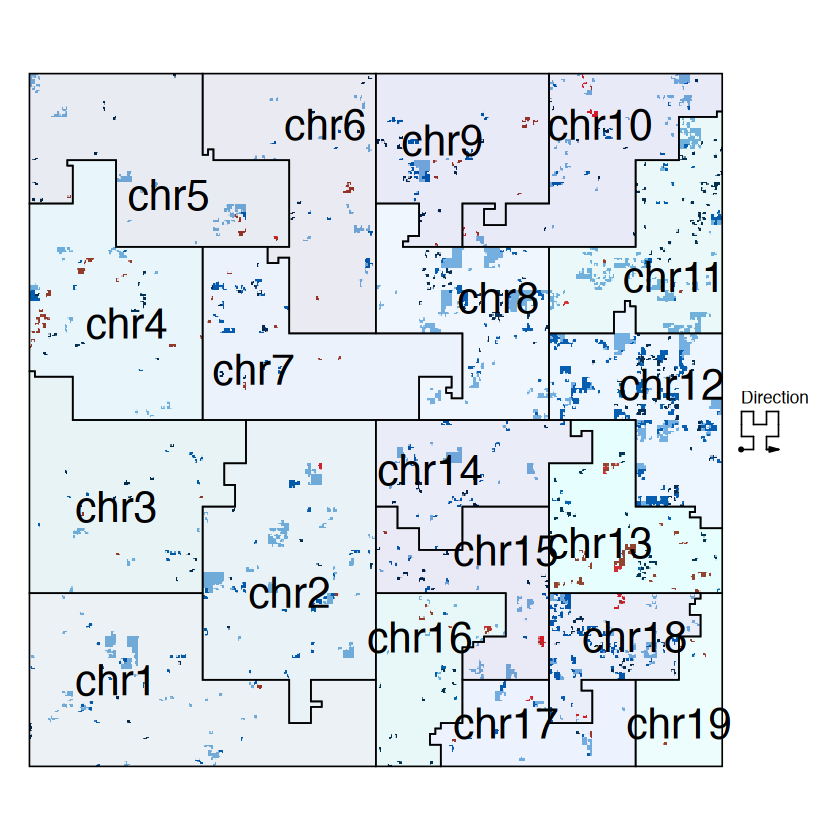

  Plotted   162 bins for 'A->B'
  Plotted    45 bins for 'B->A'
  Plotted   210 bins for 'wB->sB'
  Plotted   135 bins for 'sB->wB'
  Plotted  1020 bins for 'sA->wA'


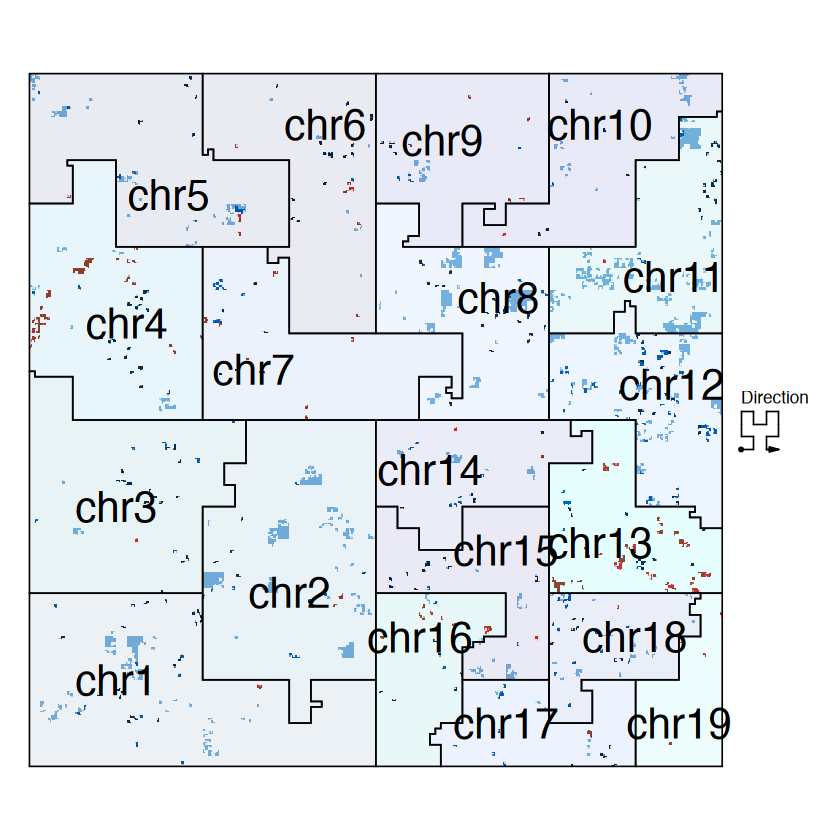

In [15]:
for (filename in filenames) {  
    input_file  <- paste0("~/SIRT6/HiC/!Katia_paper/Rebuttal/", filename, ".csv")               # <-- change to your file
    output_file <- paste0(filename, ".png")       # <-- change to .png if desired
    level       <- 9  # Hilbert curve level (9 → 512×512 px; 10 → 1024×1024 px)

    # 1. Read input data
    df <- read.csv(input_file, header = TRUE, row.names = 1)
    stopifnot(all(c("chrom", "start", "end", "Label") %in% colnames(df)))

    # 2. mm10 autosome chromosome lengths (UCSC mm10)
    chrom_lengths <- c(
        "chr1"  = 195471971, "chr2"  = 182113224, "chr3"  = 160039680,
        "chr4"  = 156508116, "chr5"  = 151834684, "chr6"  = 149736546,
        "chr7"  = 145441459, "chr8"  = 129401213, "chr9"  = 124595110,
        "chr10" = 130694993, "chr11" = 122082543, "chr12" = 120129022,
        "chr13" = 120421639, "chr14" = 124902244, "chr15" = 104043685,
        "chr16" = 98207768,  "chr17" = 94987271,  "chr18" = 90702639,
        "chr19" = 61431566
    )

    # 3. Standardize chromosome names & filter
    if (!any(df$chrom %in% names(chrom_lengths))) {
        df$chrom <- paste0("chr", df$chrom)
    }

    # Keep autosomes 1-19 only (exclude chrX, chrY, chrM)
    df <- df[df$chrom %in% names(chrom_lengths), ]
    stopifnot(nrow(df) > 0)

    # 4. Create GRanges for significant bins
    sig.gr <- GRanges(
        seqnames = df$chrom,
        ranges   = IRanges(start = df$start + 1, end = df$end),
        Label    = df$Label
    )

    # 5. Assign colours to each transition type
    labels   <- unique(df$Label)
    n_labels <- length(labels)

    labels   <- unique(df$Label)
    n_labels <- length(labels)

    label_colors <- c(
        "A->B"   = '#0057a9',
        "B->A"   = '#E41A1C',
        "wB->sB" = '#002242',
        "sB->wB" = '#a13118',
        "sA->wA" = '#78b0de',
        "wA->sA" = '#841012'
    )

    # 6. GRanges for chromosome backgrounds
    bg.gr <- GRanges(
      seqnames = names(chrom_lengths),
      ranges   = IRanges(start = rep(1L, length(chrom_lengths)), end = chrom_lengths)
    )

    # 7. Build GenomicHilbertCurve
    hc <- GenomicHilbertCurve(
      chr     = names(chrom_lengths),
      level   = level,
      mode    = "pixel",
      newpage = TRUE
    )


    # 8. Overlay significant bins by transition type
    for (lab in labels) {
        sub.gr <- sig.gr[sig.gr$Label == lab]
        hc_layer(hc, sub.gr, col = label_colors[lab])
        cat(sprintf("  Plotted %5d bins for '%s'\n", length(sub.gr), lab))
    }

    # 9. Add chromosome map with labels on the curve
    chr_labels <- names(chrom_lengths)#gsub("^chr", "", names(chrom_lengths))
    names(chr_labels) <- names(chrom_lengths)

    hc_map(hc,
       add       = TRUE,
       labels    = chr_labels,
       fill      = rcolors,
       border    = "black",
       labels_gp = gpar(fontsize = 25, col = "black", fontface = "bold"))

}

## Circular plots

In [17]:
library(circlize)
library(RColorBrewer)
library(ComplexHeatmap)

In [18]:
chrom_lengths <- c(
  "chr1"  = 195471971, "chr2"  = 182113224, "chr3"  = 160039680,
  "chr4"  = 156508116, "chr5"  = 151834684, "chr6"  = 149736546,
  "chr7"  = 145441459, "chr8"  = 129401213, "chr9"  = 124595110,
  "chr10" = 130694993, "chr11" = 122082543, "chr12" = 120129022,
  "chr13" = 120421639, "chr14" = 124902244, "chr15" = 104043685,
  "chr16" =  98207768, "chr17" =  94987271, "chr18" =  90702639,
  "chr19" =  61431566
)

In [19]:
filenames <- c("Adult->S6-KO_bins", "Adult->Old_bins", "Control->Step1_bins", "Control->Step2_bins")

In [20]:
extend_chromosomes = function(bed, chromosome, prefix = "zoom_") {
    zoom_bed = bed[bed[[1]] %in% chromosome, , drop = FALSE]
    zoom_bed[[1]] = paste0(prefix, zoom_bed[[1]])
    rbind(bed, zoom_bed)
}

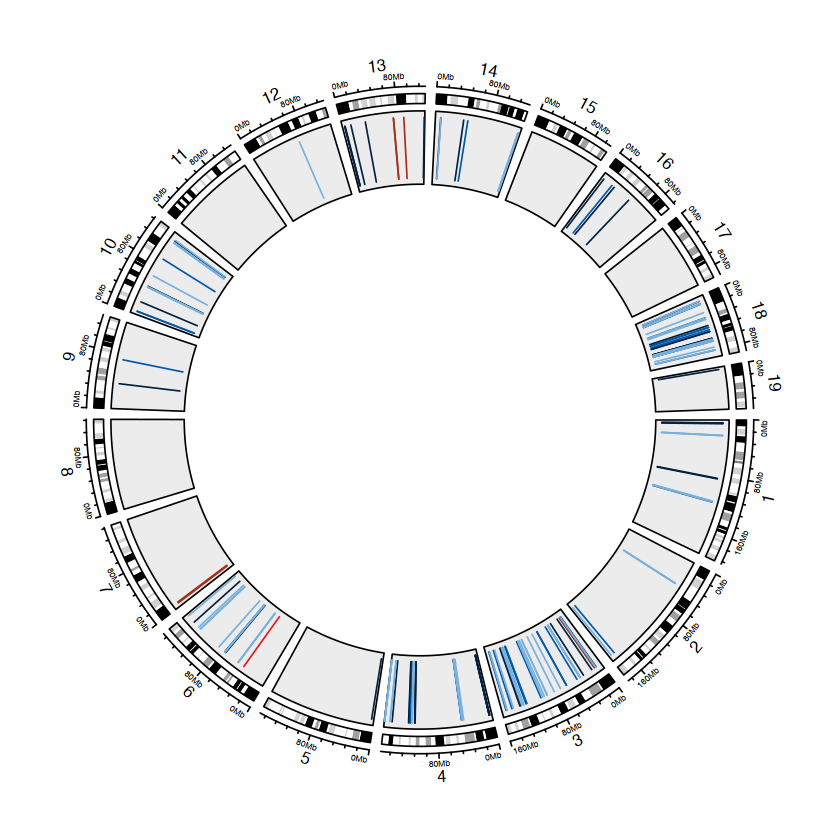

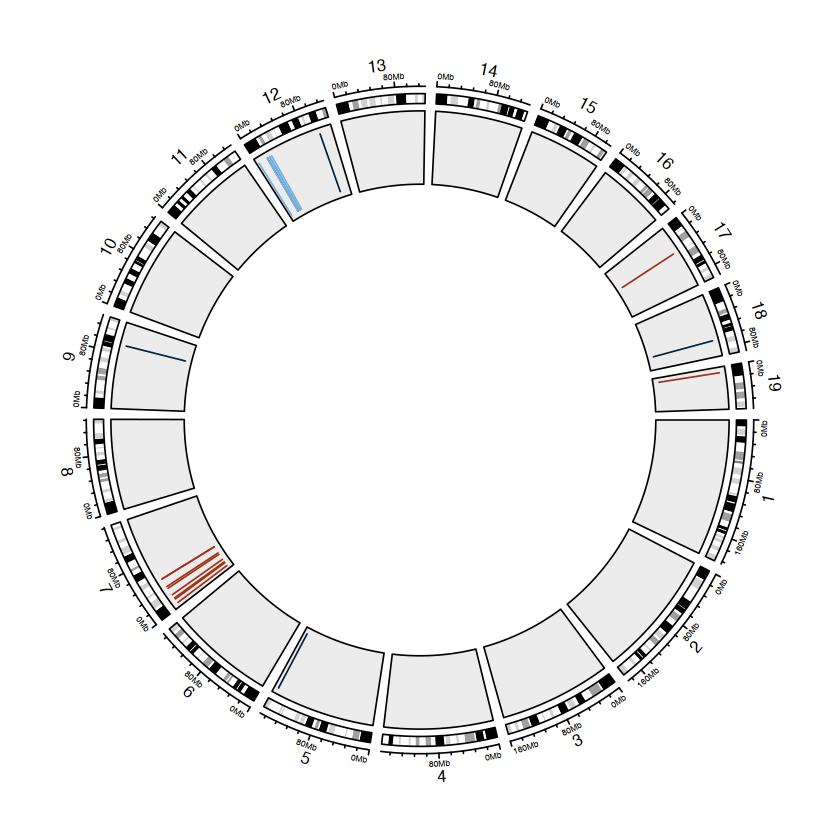

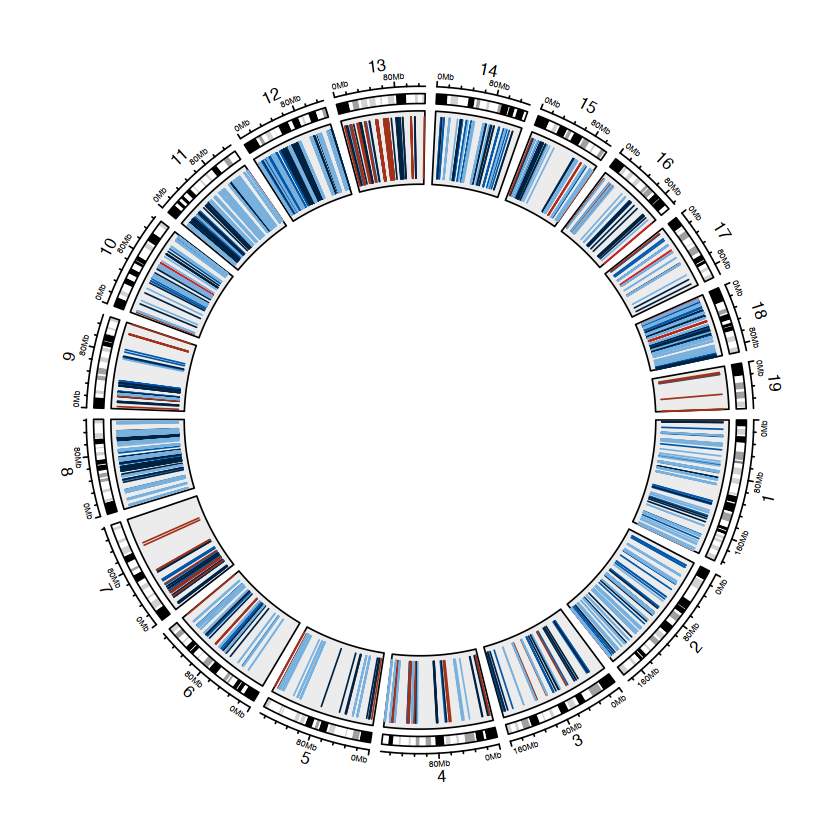

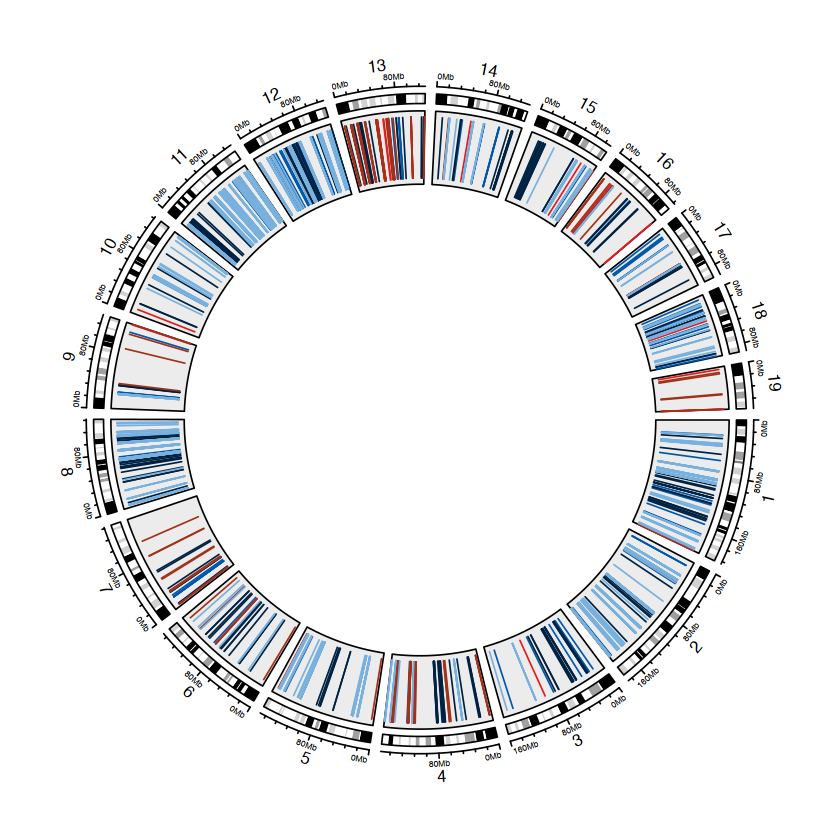

In [21]:
for (filename in filenames) {  
    input_file  <- paste0("~/SIRT6/HiC/!Katia_paper/Rebuttal/", filename, ".csv") 
    output_file <- paste0(filename, ".png")  # Change to .png if desired

    df <- read.csv(input_file, header = TRUE, row.names = 1)
    stopifnot(all(c("chrom", "start", "end", "Label") %in% colnames(df)))

    if (!any(df$chrom %in% names(chrom_lengths))) {
      df$chrom <- paste0("chr", df$chrom)
    }
    df <- df[df$chrom %in% names(chrom_lengths), ]
    stopifnot(nrow(df) > 0)

    labels   <- unique(df$Label)
    n_labels <- length(labels)


    label_colors <- c(
      "A->B"   = '#0057a9',
      "B->A"   = '#E41A1C',
      "wB->sB" = '#002242',
      "sB->wB" = '#a13118',
      "sA->wA" = '#78b0de',
      "wA->sA" = '#841012'
    )

    # Map colors back to the dataframe (vectorized for speed)
    df$col <- label_colors[df$Label]

    circos.clear()
    circos.par("gap.degree" = rep(c(2), 19))

    circos.initializeWithIdeogram(species = "mm10", chromosome.index = paste0("chr", seq(1:19)), draw.chr.prefix = F)

    circos.track(ylim = c(0, 1), bg.border = "black", bg.col = "#e5e5e5b9", panel.fun = function(x, y) {
      chr    <- CELL_META$sector.index
      sub_df <- df[df$chrom == chr, , drop = FALSE]
  
    if (nrow(sub_df) > 0) {
      circos.rect(sub_df$start, 0, sub_df$end, 1, 
                col = sub_df$col, border = sub_df$col)
    }
  })

}